In [1]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = {
    'cust_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'credit_score': [720, 690, 710, 680, 730, 440, 340, 340, 380, 400],
    '_Income': [50000, 60000, 55000, 52000, 58000, 6200, 4800, 4900, 6100, 5300],
    'Status':[1, 1, 1, 1, 1, 1, 0, 0, 0, 0]
}

df = pd.DataFrame(data)

df.head(2)

,cust_id,credit_score,_Income,Status
0,1,720,50000,1
1,2,690,60000,1


In [4]:
X = df[['credit_score', '_Income']]
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.01, random_state=42)

In [6]:


knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train) # this is where the model learns but in KNN it just stores the data
y_pred = knn.predict(X_test)    


In [7]:
X_test_copy = X_test.copy()
X_test_copy['Predicted_Status'] = y_pred
X_test_copy['Actual_Status'] = y_test.values
X_test_copy.head()

,credit_score,_Income,Predicted_Status,Actual_Status
8,380,6100,0,0


In [11]:
# As a assignment: try to implement KNN from scratch without using sklearn

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []
        for x in X.values:
            distances = [euclidean_distance(x, x_train) for x_train in self.X_train.values]
            k_indices = np.argsort(distances)[:self.k]
            k_nearest_labels = [self.y_train.iloc[i] for i in k_indices]
            predictions.append(np.bincount(k_nearest_labels).argmax())
        return np.array(predictions)
    

knn_scratch = KNN(k=2)
knn_scratch.fit(X_train, y_train)
y_pred_scratch = knn_scratch.predict(X_test)
y_pred_scratch

array([0])

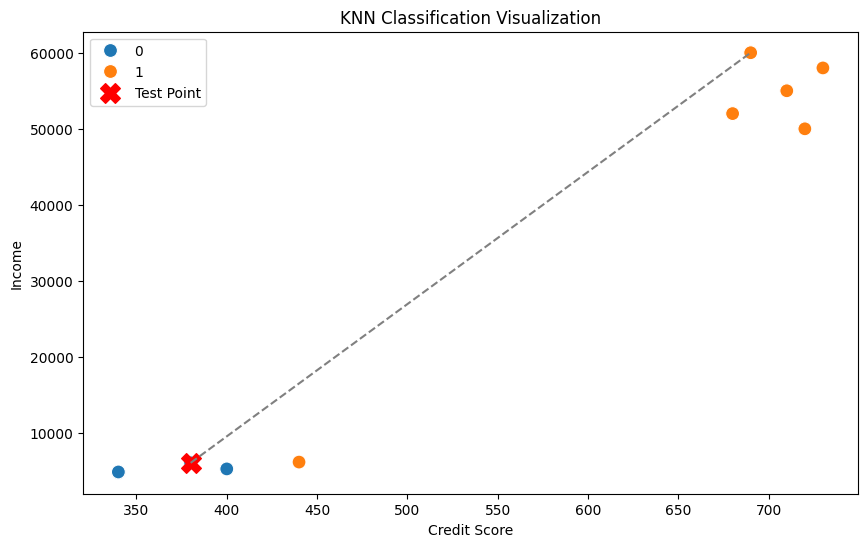

In [10]:
# lets visualize the data points and their classifications # also show distances
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='credit_score', y='_Income', hue='Status', s=100)
plt.scatter(X_test['credit_score'], X_test['_Income'], color='red', marker='X', s=200, label='Test Point')

# Show distances
for i in range(len(X_test)):
    plt.plot([X_test['credit_score'].iloc[i], X_train['credit_score'].iloc[y_pred_scratch[i]]],
             [X_test['_Income'].iloc[i], X_train['_Income'].iloc[y_pred_scratch[i]]], color='gray', linestyle='--')

plt.title('KNN Classification Visualization')
plt.xlabel('Credit Score')
plt.ylabel('Income')
plt.legend()
plt.show()


### Reference
- https://medium.com/swlh/k-nearest-neighbor-ca2593d7a3c4

In [24]:
# lets create classfication data from skelearn
from sklearn.datasets import make_classification, make_regression

X, y = make_classification(n_samples=5000, n_features=10, n_classes=2, random_state=42)
df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df["target"] = y
df.head(2)

#

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,1.864200,-2.371159,-0.671308,-0.666403,1.313473,0.089198,-2.025296,-0.673544,-0.696461,-0.076865,0
1,0.335487,0.271304,-2.020151,-0.026345,1.237954,-0.821913,-0.135680,0.317409,0.385470,0.133730,0


In [6]:
df.shape
df.target.value_counts()    

target
1    2508
0    2492
Name: count, dtype: int64

In [29]:
# split the data into train and test 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# shape of training data
X_train.shape, y_train.shape

((4000, 10), (4000,))

Accuracy for k=3: 0.852
Accuracy for k=5: 0.859
Accuracy for k=7: 0.861
Accuracy for k=9: 0.867
Accuracy for k=11: 0.869
Accuracy for k=13: 0.869
Accuracy for k=15: 0.878
Accuracy for k=17: 0.874
Accuracy for k=19: 0.874
Accuracy for k=21: 0.875
Accuracy for k=23: 0.873


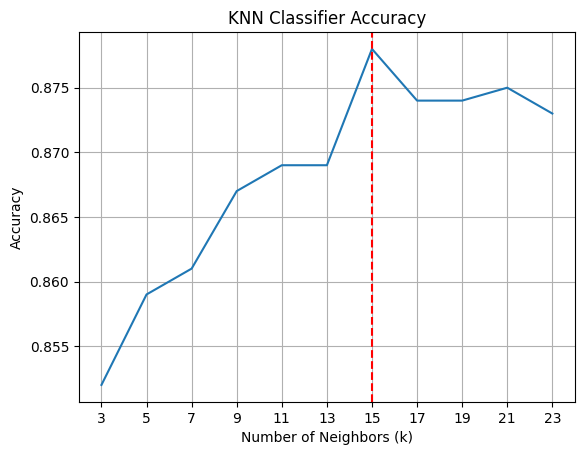

In [15]:
k = [3, 5, 7, 9,11,13,15,17,19,21,23]
accuracy_scores = []
for i in k:
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train) # here your model will learn
    y_pred = knn.predict(X_test) # you are predicting on testing data
    accuracy = accuracy_score(y_test, y_pred) # you are comparing with the true labels
    accuracy_scores.append(accuracy)
    print(f"Accuracy for k={i}: {accuracy}")


# plot it
import matplotlib.pyplot as plt
# label optimal k value
optimal_k = k[accuracy_scores.index(max(accuracy_scores))]

plt.plot(k, accuracy_scores)
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Classifier Accuracy")
plt.xticks(k)
plt.grid()
plt.show()

In [17]:
# finally k= 15 will be best value - 
# I will re-train my model with update parameter
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Final accuracy with k={optimal_k}: {accuracy}")

# save this model
import joblib
joblib.dump(knn, 'knn_model.joblib')    

Final accuracy with k=15: 0.878


['knn_model.joblib']

In [20]:
X_train[0]

array([-1.06433071,  1.33980388,  0.0940354 , -0.3182478 , -0.60686802,
       -0.71645852, -1.34384045,  2.0082602 , -0.51409134,  1.09156754])

In [23]:
# you can use your model
input_data = X_train[2].reshape(1, -1)
model = joblib.load('knn_model.joblib')
prediction = model.predict(input_data)
print(f"Prediction: {prediction}")


Prediction: [1]


In [28]:
# regression use case
X, y = make_regression(n_samples=5000, n_features=10, noise=0.5, random_state=42)
df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])


# split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [30]:
# initialize the model
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
mse = np.mean((y_test - y_pred) ** 2)
print(f"Mean Squared Error (MSE) for KNN Regression: {mse}")

Mean Squared Error (MSE) for KNN Regression: 3956.604167299243


Mean Squared Error (MSE) for KNN Regression with K=1: 7614.66281693174
Mean Squared Error (MSE) for KNN Regression with K=3: 4541.449769510479
Mean Squared Error (MSE) for KNN Regression with K=5: 3956.604167299243
Mean Squared Error (MSE) for KNN Regression with K=7: 3710.5877215177143
Mean Squared Error (MSE) for KNN Regression with K=9: 3648.998191059218
Mean Squared Error (MSE) for KNN Regression with K=11: 3702.8230562079184
Mean Squared Error (MSE) for KNN Regression with K=13: 3734.294637538598
Mean Squared Error (MSE) for KNN Regression with K=15: 3820.4181306237206
Mean Squared Error (MSE) for KNN Regression with K=17: 3899.6359099005304
Mean Squared Error (MSE) for KNN Regression with K=19: 3967.3530206092864
Mean Squared Error (MSE) for KNN Regression with K=21: 4044.023951601482


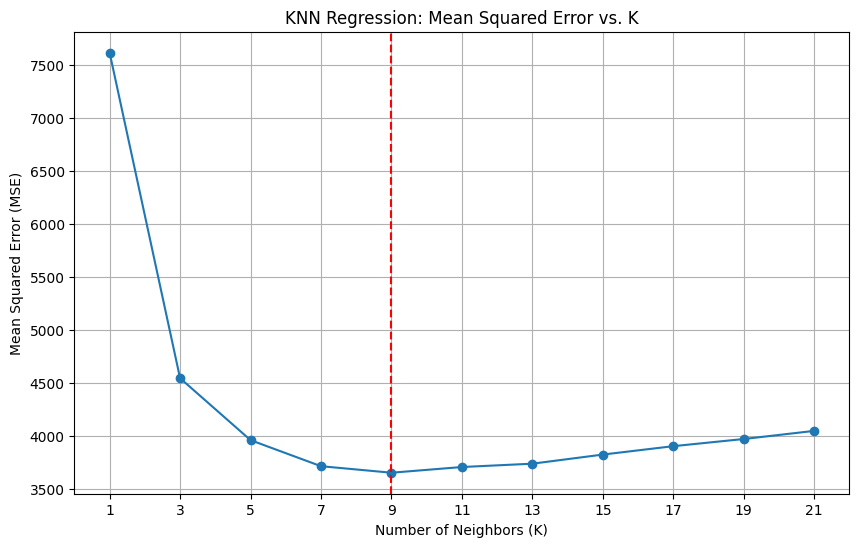

In [33]:
# if you try different value of K
k_values = [1, 3, 5, 7, 9,11,13,15,17,19,21]
mse_values = []
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse = np.mean((y_test - y_pred) ** 2)
    mse_values.append(mse)
    print(f"Mean Squared Error (MSE) for KNN Regression with K={k}: {mse}")


# plot it
import matplotlib.pyplot as plt

# optimal value of k
optimal_k = k_values[np.argmin(mse_values)]
plt.figure(figsize=(10, 6))
plt.plot(k_values, mse_values, marker='o')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'Optimal k={optimal_k}')
plt.title("KNN Regression: Mean Squared Error vs. K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Squared Error (MSE)")
plt.xticks(k_values)
plt.grid()
plt.show()


In [34]:
# here best model will be at k= 9
model = KNeighborsRegressor(n_neighbors=optimal_k)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = np.mean((y_test - y_pred) ** 2)
print(f"Mean Squared Error (MSE) for KNN Regression with Optimal K={optimal_k}: {mse}")

Mean Squared Error (MSE) for KNN Regression with Optimal K=9: 3648.998191059218


In [35]:
# imblance data set
X, y = make_classification(n_samples=1000, n_features=10, n_classes=2, weights=[0.9, 0.1], random_state=42)

df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])
df["target"] = y
df.head(2)

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,0.964799,-0.066449,0.986768,-0.358079,0.997266,1.181890,-1.615679,-1.210161,-0.628077,1.227274,0
1,1.230350,-0.566395,1.169487,0.831617,-1.176962,1.820544,-1.788927,-0.984534,-1.091341,0.209470,0


In [46]:
df.target.value_counts()

target
0    897
1    103
Name: count, dtype: int64

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [41]:
# lets do the experiment on imbalanced data and observe the accuracy (for imbalance dont use accuracy)
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for KNN Classifier with K=3: {accuracy}")

Accuracy for KNN Classifier with K=3: 0.93


In [42]:
print('Shape of original training data:', X_train.shape)


Shape of original training data: (800, 10)


In [49]:
# imbalance to balanced ?? using imblearn 
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)
print('Shape of resampled training data:', X_resampled.shape)

# we can train the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_resampled, y_resampled)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for KNN Classifier with K=5: {accuracy}")


Shape of resampled training data: (1444, 10)
Accuracy for KNN Classifier with K=5: 0.895


In [51]:
from imblearn.under_sampling import RandomUnderSampler

X_resampled, y_resampled = RandomUnderSampler().fit_resample(X_train, y_train)
print('Shape of resampled training data:', X_resampled.shape)

# we can train the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_resampled, y_resampled)
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for KNN Classifier with K=5: {accuracy}")

Shape of resampled training data: (156, 10)
Accuracy for KNN Classifier with K=5: 0.835
